### AI-Powered Alcohol Label Verification Prototype

This project explores a simple AI-assisted method for reviewing alcohol beverage labels. The system extracts text from an uploaded label image and compares key label information against expected application data. The goal is to help identify obvious matches, mismatches, or items that may require manual review.

In [1]:
# Importing Libraries

from PIL import Image
import pytesseract
import pandas as pd
import re
from rapidfuzz import fuzz

In [2]:
# Connecting Python to Tesseract OCR

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

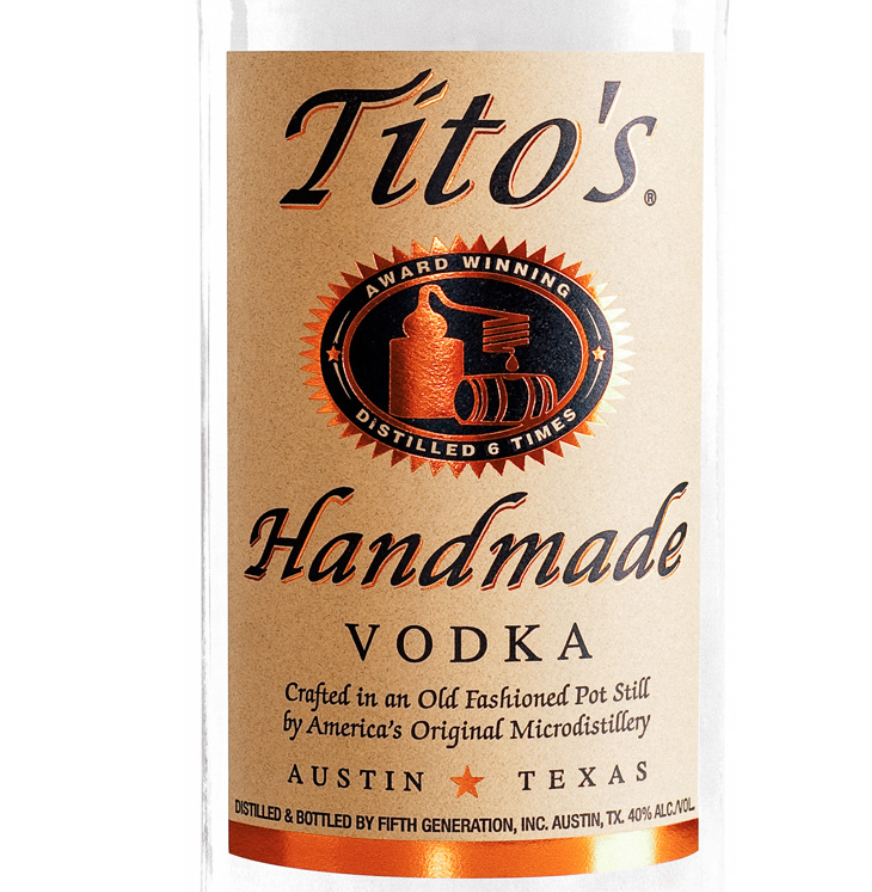

In [3]:
# Loading a sample label

img = Image.open("sample_label.png")
display(img)

A sample alcohol label was loaded for testing.

In [4]:
# Extracting text from the label

ocr_text = pytesseract.image_to_string(img)

print(ocr_text)

Crafted in an Oli Fashioned Pot Stil

by America’s Original Microdistilley

AUSTIN TEXAS
a lea GENERATION, INC, AUSTIN, Tx 40% ACNE



Tesseract OCR is used as an existing tool to convert the label image into readable text. The project does not build an OCR model from scratch.

In [5]:
# Entering the Application Information

application = {
    "brand": "Tito's",
    "class_type": "Vodka",
    "abv": 40,
    "net_contents": "750 ML",
}

This represents information that an agent would already have from the application and wants to verify against the submitted label.

In [6]:
# Comparison function for text fields

def compare_text(expected, label_text):
    
    score = fuzz.partial_ratio(
        expected.upper(),
        label_text.upper()
    )

    if score >= 80:
        return "PASS"
    
    else:
        return "REVIEW"

In [7]:
# Finding Alcohol Content (ABV)

def find_abv(text):
    
    match = re.search(
        r"(\d{1,2}(?:\.\d+)?)\s*%",
        text
    )

    if match:
        return float(match.group(1))

    return None

In [8]:
# Finding Net Contents

def find_net_contents(text):
    
    match = re.search(
        r"(\d+(?:\.\d+)?)\s*(ML|L|CL)",
        text.upper()
    )

    if match:
        return f"{match.group(1)} {match.group(2)}"

    return None

In [9]:
# Checking for Government Warning

def check_government_warning(text):
    
    if "GOVERNMENT WARNING" in text.upper():
        return "PASS"
    
    else:
        return "REVIEW"

In [10]:
# Running the checks

# Brand Name
brand_result = compare_text(
    application["brand"],
    ocr_text
)


# Class / Type
class_result = compare_text(
    application["class_type"],
    ocr_text
)


# Alcohol Content
detected_abv = find_abv(
    ocr_text
)

if detected_abv is None:
    abv_result = "REVIEW"

elif detected_abv == application["abv"]:
    abv_result = "PASS"

else:
    abv_result = "MISMATCH"


# Net Contents
detected_contents = find_net_contents(
    ocr_text
)

if detected_contents is None:
    contents_result = "REVIEW"

elif detected_contents == application["net_contents"]:
    contents_result = "PASS"

else:
    contents_result = "MISMATCH"


# Government Warning
warning_result = check_government_warning(
    ocr_text
)

In [11]:
# Displaying Results

results = pd.DataFrame([
    
    {
        "Field": "Brand Name",
        "Expected": application["brand"],
        "Detected": "See extracted label text",
        "Result": brand_result
    },
    
    {
        "Field": "Class / Type",
        "Expected": application["class_type"],
        "Detected": "See extracted label text",
        "Result": class_result
    },
    
    {
        "Field": "Alcohol Content",
        "Expected": f"{application['abv']}%",
        "Detected": (
            f"{detected_abv}%"
            if detected_abv is not None
            else "Not detected"
        ),
        "Result": abv_result
    },
    
    {
        "Field": "Net Contents",
        "Expected": application["net_contents"],
        "Detected": (
            detected_contents
            if detected_contents is not None
            else "Not detected"
        ),
        "Result": contents_result
    },
    
    {
        "Field": "Government Warning",
        "Expected": "Present",
        "Detected": (
            "Detected"
            if warning_result == "PASS"
            else "Not detected"
        ),
        "Result": warning_result
    }
])

results

,Field,Expected,Detected,Result
0,Brand Name,Tito's,See extracted label text,REVIEW
1,Class / Type,Vodka,See extracted label text,REVIEW
2,Alcohol Content,40%,40.0%,PASS
3,Net Contents,750 ML,Not detected,REVIEW
4,Government Warning,Present,Not detected,REVIEW


In [12]:
# Overall Verification Result

if "MISMATCH" in results["Result"].values:
    overall_result = "MISMATCH FOUND"

elif "REVIEW" in results["Result"].values:
    overall_result = "MANUAL REVIEW REQUIRED"

else:
    overall_result = "PASS"


print("Overall Result:", overall_result)

Overall Result: MANUAL REVIEW REQUIRED


### Limitations

- OCR accuracy may decrease for decorative fonts, glare, curved bottles, or low-quality images.
- The prototype checks only a small set of common label fields.
- A REVIEW result means the system could not confidently verify the field and a human should inspect it.
- Government warning detection currently checks for the presence of the warning heading and does not evaluate all formatting requirements.
- The prototype does not replace regulatory judgment.